---

## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---


---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

---


---

# PARTIE 6 : GRAD-CAM (Camille)

---


In [ ]:
# Imports
# Version 1.0

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import medmnist
from medmnist import PathMNIST, INFO
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
print("Imports OK")


In [ ]:
# Versions
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")


In [ ]:
# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")


In [ ]:
# Constantes et dataset
DATA_DIR = os.path.join(".", "data")
NORM_MEAN = [0.7405, 0.5330, 0.7058]
NORM_STD  = [0.1237, 0.1768, 0.1244]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
N_CLASSES = 9

train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASS_NAMES = list(labels_names.values())

notebook_start_time = time.time()

print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Lien avec notebook 1 établi")


In [ ]:
# Charger le ResNet fine-tuning depuis le fichier sauvegardé
# Permet de faire tourner ce notebook indépendamment du notebook 4
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, N_CLASSES)
model.load_state_dict(torch.load(os.path.join(DATA_DIR, 'resnet_finetune_model.pth'), map_location=device))
model = model.to(device)
model.eval()

# Charger le test set avec transform ResNet
resnet_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
test_rn = PathMNIST(split='test', transform=resnet_transform, download=False, root=DATA_DIR)

print(f"Modèle ResNet chargé depuis {os.path.join(DATA_DIR, 'resnet_finetune_model.pth')}")
print(f"Test set : {len(test_rn)} images")
print("✓ Modèle et données prêts pour Grad-CAM")


In [ ]:
# Grad-CAM
import torch.nn.functional as F
import matplotlib.cm as cm

class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.activations  = None
        # saved by forward hook, what layer has detected
        self.gradients    = None
        # saved by backward hook, how each activation contributed to prediction
        self._register_hooks()

    def _register_hooks(self):
        # Forward hook: runs AFTER the layer computes its output
        # Saves the activation maps (what the layer detected)
        def forward_hook(module, input, output):
            self.activations = output.detach()
            # get values

        # Backward hook: runs AFTER backprop passes through this layer
        # Saves the gradients (how important each activation was)
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, input_tensor, cls=None):
        self.model.eval()

        # Step 1 Forward pass (also triggers forward_hook)
        # Put the image in the network
        # Hook saves activation of the layer
        logits = self.model(input_tensor)
        if cls is None:
            cls = logits.argmax(dim=1).item()

        # Step 2 Backward pass for the chosen class (triggers backward_hook)
        self.model.zero_grad()
        logits[0, cls].backward()
        # Compute the gradient for the class of interest
        # Not the global loss
        # Meaning : how each parameter contributed to the score

        # Step 3 Global average pooling of gradients, one weight per channel
        # gradients shape: [1, C, h, w]
        # weights shape: [1, C, 1, 1]  (mean over spatial dims h, w)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        # Weighted sum of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        # Step 4 ReLU: only keep regions that positively contributed
        # We keep only areas which increased the class scoring
        cam = F.relu(cam)

        # Step 5 Normalisation to [0, 1]
        cam = cam.squeeze()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        # Avoid division by 0
        return cam.cpu().numpy(), cls


In [ ]:
# Helper functions

def overlay_heatmap(img_tensor, cam, alpha=0.45):
    # Superpose Grad-CAM heatmap onto the original image

    H, W = img_tensor.shape[1], img_tensor.shape[2]

    # Resize image size using bilinear interpolation
    cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_r = F.interpolate(cam_t, size=(H, W), mode='bilinear',
                          align_corners=False).squeeze().numpy()

    # Bring image back to displayable [0,1] range
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    # Convert to RGB using jet colormap (blue=low, red=high attention)
    heatmap = cm.jet(cam_r)[:, :, :3]

    # Alpha blend
    blended = (1 - alpha) * img_np + alpha * heatmap
    return np.clip(blended, 0, 1), cam_r


def find_example(dataset, class_idx, model, device, correct=True):
    # Find a correct and incorrect image
    model.eval()
    for img, label in dataset:
        lbl = int(label)
        if lbl != class_idx:
            continue
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
        if correct and pred == lbl:
            return img, lbl, pred
        if not correct and pred != lbl:
            return img, lbl, pred
    return None, None, None


def find_any_wrong(dataset, model, device):
    # Returns the first misclassified image found in dataset
    # For question 6.2
    model.eval()
    for img, label in dataset:
        lbl = int(label)
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
        if pred != lbl:
            return img, lbl, pred
    return None, None, None


In [ ]:
# Attach Grad-CAM to ResNet-18
# We hook into layer4[1].conv2 : the very last convolutional layer.
# Early layers detect low-level features (edges, colours)
# Late layers detect high-level semantic features (tissue patterns)
# The last conv layer gives the most interpretable spatial heatmap
# It combines both spatial resolution and semantic meaning

target_layer = resnet_full.layer4[1].conv2
gcam = GradCAM(model=resnet_full, target_layer=target_layer)

print("Grad-CAM ready.")
print("Target layer : resnet_full.layer4[1].conv2")
print("Output shape of this layer : [1, 512, 7, 7] for 224×224 inputs")
print("(7×7 heatmap will be upscaled to 224×224 for overlay)")


Grad-CAM ready.
Target layer : resnet_full.layer4[1].conv2
Output shape of this layer : [1, 512, 7, 7] for 224×224 inputs
(7×7 heatmap will be upscaled to 224×224 for overlay)


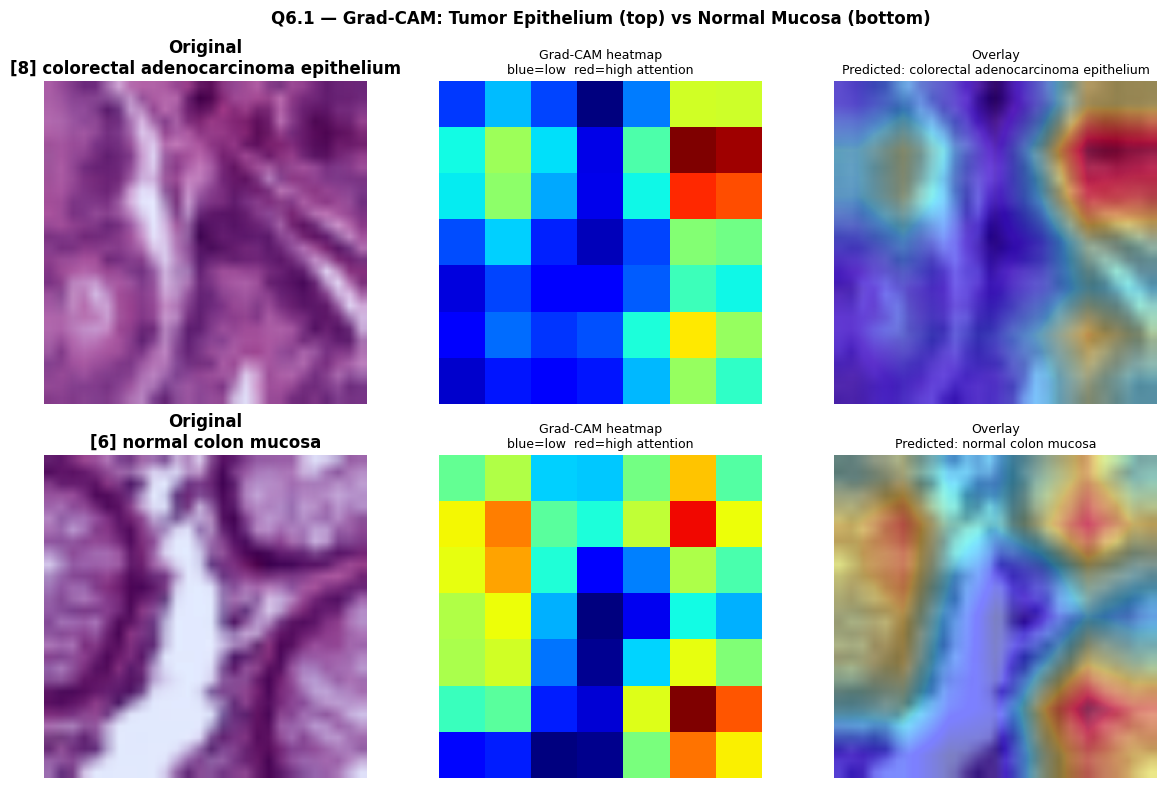

In [ ]:
# Q6.1 Tumor Epithelium vs Normal Mucosa
TUMOR    = 8   # Tumor Epithelium
MUCOSA   = 6   # Normal Mucosa

img_t, lbl_t, pred_t = find_example(test_rn, TUMOR,  resnet_full, DEVICE, correct=True)
img_m, lbl_m, pred_m = find_example(test_rn, MUCOSA, resnet_full, DEVICE, correct=True)

cam_t, _ = gcam(img_t.unsqueeze(0).to(DEVICE), cls=TUMOR)
cam_m, _ = gcam(img_m.unsqueeze(0).to(DEVICE), cls=MUCOSA)

ov_t, _ = overlay_heatmap(img_t, cam_t)
ov_m, _ = overlay_heatmap(img_m, cam_m)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, (img, cam, ov, lbl, pred, cls_idx) in enumerate([
        (img_t, cam_t, ov_t, lbl_t, pred_t, TUMOR),
        (img_m, cam_m, ov_m, lbl_m, pred_m, MUCOSA)]):

    # original image
    disp = img.permute(1,2,0).numpy()
    disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)
    axes[row,0].imshow(disp)
    axes[row,0].set_title(f"Original\n[{cls_idx}] {CLASSES[cls_idx]}", fontweight='bold')
    axes[row,0].axis('off')

    # raw heatmap
    axes[row,1].imshow(cam, cmap='jet', vmin=0, vmax=1)
    axes[row,1].set_title("Grad-CAM heatmap\nblue=low  red=high attention", fontsize=9)
    axes[row,1].axis('off')

    # overlay
    axes[row,2].imshow(ov)
    axes[row,2].set_title(f"Overlay\nPredicted: {CLASSES[pred]}", fontsize=9)
    axes[row,2].axis('off')

plt.suptitle("Q6.1 — Grad-CAM: Tumor Epithelium (top) vs Normal Mucosa (bottom)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_q6_1.png', dpi=120, bbox_inches='tight')
plt.show()


### Q6.1: Heatmap Differences Between Tumor Epithelium and Normal Mucosa

**Tumor Epithelium** : activation concentrated in the top right of the image. Localised and specific. Area with dense cell population. Rest of the image is blue: model ignores it

**Normal Mucosa** : heatmap is very different. Activation is dispersed in a few distinct zones. Ignore le lumen (inside of the colon).

**Key difference in one sentence:** Activation is localisated on the tumor vs peripheric activation in the healthy tissue. Model learned biological features to distinguish both classes


Misclassified image found:
  True class      : 8  (colorectal adenocarcinoma epithelium)
  Predicted class : 3  (lymphocytes)


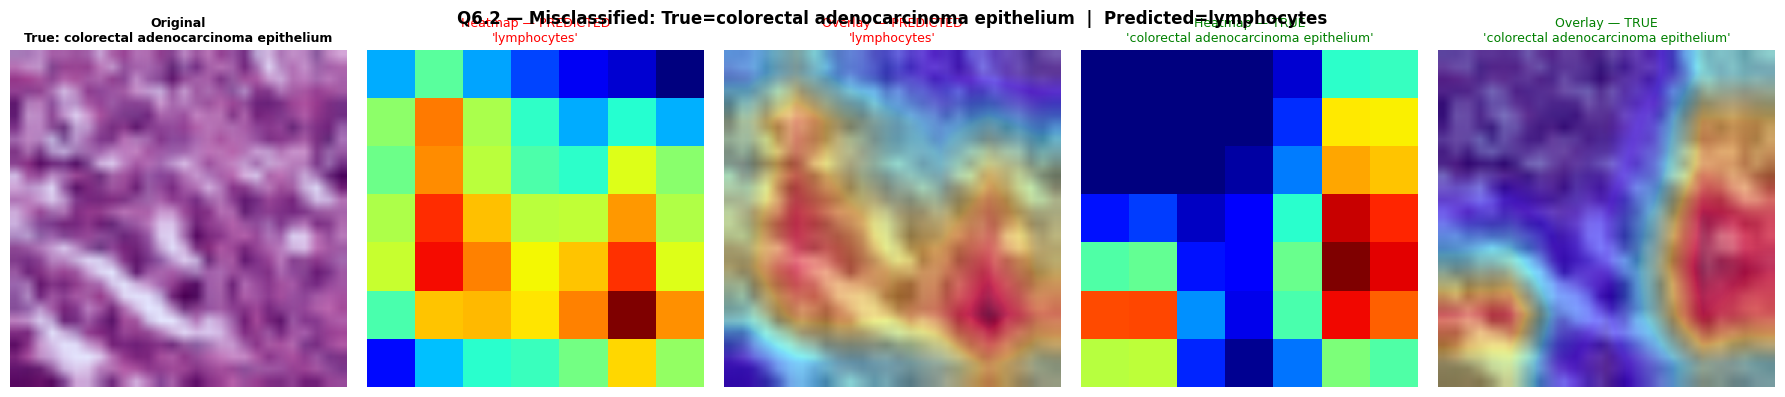

In [ ]:
# Q6.2: Misclassified image: heatmap for both classes
img_w, true_cls, pred_cls = find_any_wrong(test_rn, resnet_full, DEVICE)

print(f"Misclassified image found:")
print(f"  True class      : {true_cls}  ({CLASSES[true_cls]})")
print(f"  Predicted class : {pred_cls}  ({CLASSES[pred_cls]})")

# Heatmap explaining WHY the model chose the wrong class
cam_pred, _ = gcam(img_w.unsqueeze(0).to(DEVICE), cls=pred_cls)
# Heatmap showing what would have led to the correct class
cam_true, _ = gcam(img_w.unsqueeze(0).to(DEVICE), cls=true_cls)

ov_pred, _ = overlay_heatmap(img_w, cam_pred)
ov_true, _ = overlay_heatmap(img_w, cam_true)

disp = img_w.permute(1,2,0).numpy()
disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(disp)
axes[0].set_title(f"Original\nTrue: {CLASSES[true_cls]}", fontweight='bold', fontsize=9)
axes[0].axis('off')

axes[1].imshow(cam_pred, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f"Heatmap — PREDICTED\n'{CLASSES[pred_cls]}'", fontsize=9, color='red')
axes[1].axis('off')

axes[2].imshow(ov_pred)
axes[2].set_title(f"Overlay — PREDICTED\n'{CLASSES[pred_cls]}'", fontsize=9, color='red')
axes[2].axis('off')

axes[3].imshow(cam_true, cmap='jet', vmin=0, vmax=1)
axes[3].set_title(f"Heatmap — TRUE\n'{CLASSES[true_cls]}'", fontsize=9, color='green')
axes[3].axis('off')

axes[4].imshow(ov_true)
axes[4].set_title(f"Overlay — TRUE\n'{CLASSES[true_cls]}'", fontsize=9, color='green')
axes[4].axis('off')

plt.suptitle(f"Q6.2 Misclassified: True={CLASSES[true_cls]}, Predicted={CLASSES[pred_cls]}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_q6_2.png', dpi=120, bbox_inches='tight')
plt.show()


### Q6.2: What the Two Heatmaps Reveal About the Confusion
The explanation is biological :
Tumoral tissue is very ofter infiltrated by immune cells such as lymphocytes. These immune cells can fight or help the spread of the tumor depending on different biological parameters. In the picture, accumulation of lymphocytes cells or cancer cells have a very similar profile.
The model focus on the infiltrate instead of the tumor area.


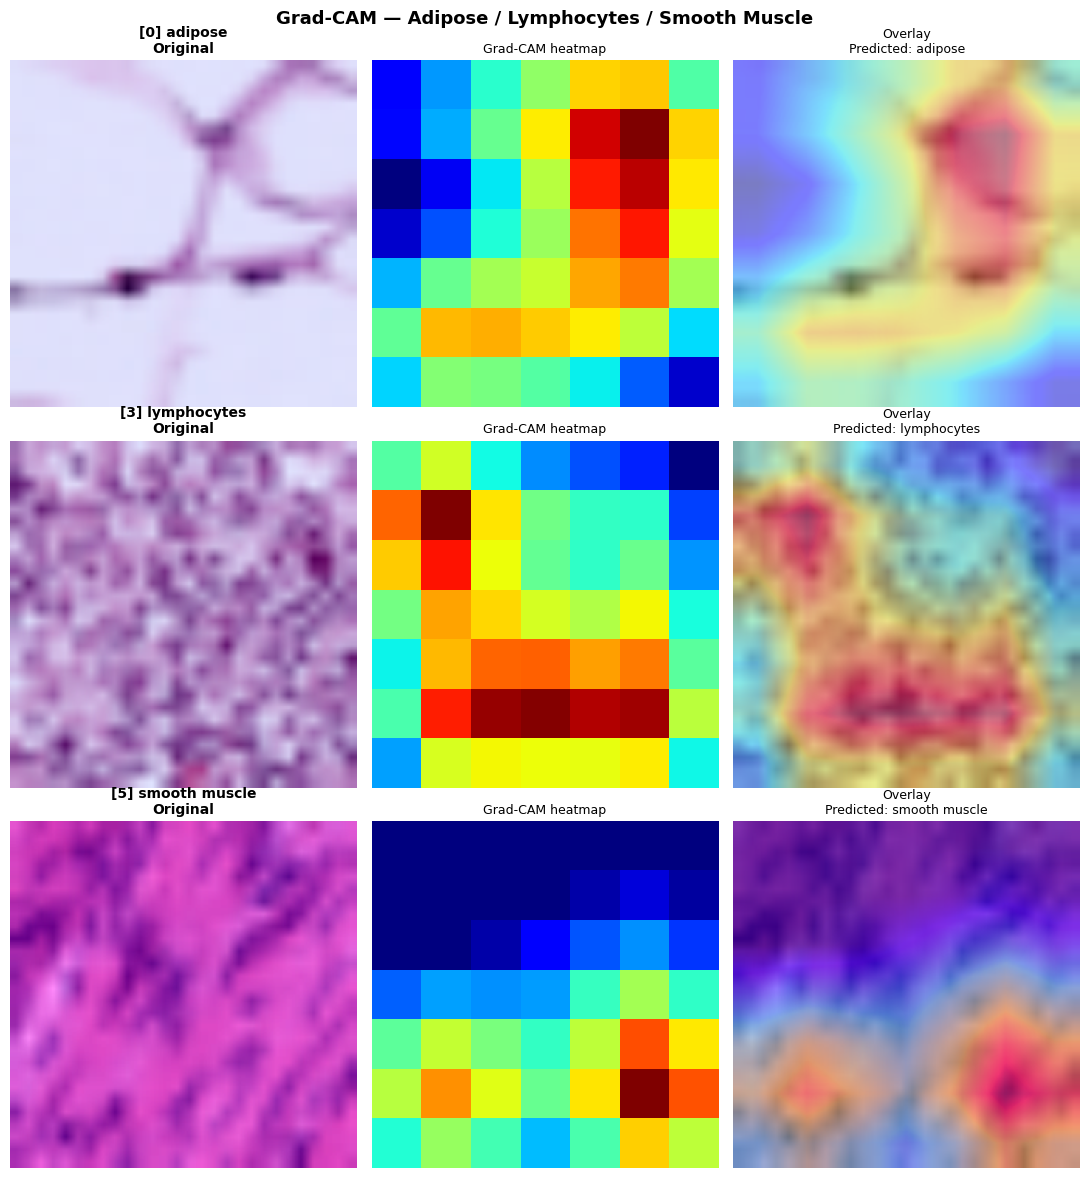

In [ ]:
# Grad-CAM for 3 more tissue types
SHOWCASE = [0, 3, 5]
# Adipose, Lymphocytes, Smooth Muscle

fig, axes = plt.subplots(len(SHOWCASE), 3, figsize=(11, 4 * len(SHOWCASE)))

for row, cls_idx in enumerate(SHOWCASE):
    img_s, lbl_s, pred_s = find_example(test_rn, cls_idx, resnet_full, DEVICE, correct=True)
    cam_s, _ = gcam(img_s.unsqueeze(0).to(DEVICE), cls=cls_idx)
    ov_s, _  = overlay_heatmap(img_s, cam_s)

    disp = img_s.permute(1,2,0).numpy()
    disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)

    axes[row,0].imshow(disp)
    axes[row,0].set_title(f"[{cls_idx}] {CLASSES[cls_idx]}\nOriginal",
                          fontweight='bold', fontsize=10)
    axes[row,0].axis('off')

    axes[row,1].imshow(cam_s, cmap='jet', vmin=0, vmax=1)
    axes[row,1].set_title("Grad-CAM heatmap", fontsize=9)
    axes[row,1].axis('off')

    axes[row,2].imshow(ov_s)
    axes[row,2].set_title(f"Overlay\nPredicted: {CLASSES[pred_s]}", fontsize=9)
    axes[row,2].axis('off')

plt.suptitle("Grad-CAM: Adipose / Lymphocytes / Smooth Muscle",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_extra.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# Temps total du notebook
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")
